In [3]:
import sys, os

sys.path.append("/burg-archive/ccce/users/phr2114/vmc")
os.environ["NVIDIA_TF32_OVERRIDE"] = "0"

import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.core.frozen_dict import freeze, unfreeze
import numpy as np

import wavefunctions, trajectory, optimization
import hamiltonian

jax.config.update("jax_enable_x64", False) # Single precision
#jax.config.update("jax_enable_x64", True)  # Double Precision

import time

import importlib

In [2]:
r_ws = 50
N = 56
tau = 65 # 1.25
dim = 2
numKpoints = 169

walkers = 64 # 1024

eqSteps      = 100 # 2000
trainSteps   = 3 # 10 # 1000
trainEqSteps = 3 # 20
evalSteps    = 3 # 10 # 1000

NUp = N // 2
NDown = N - NUp
spins = ( NUp , NDown )

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

( acceptMin , acceptMax ) = ( 0.55 , 0.65 )

class NewMessagePassingWavefunction(wavefunctions.Wavefunction):
    """
    TODO
    """
    spins : (int,int)
    dim : int
    lattice : jnp.ndarray
    kpoints : jnp.ndarray
    hiddenFeatures : int     # number of features for all MLPs
    T : int                  # number of rounds of message passing

    def setup(self):
        
        self.slaterUp = wavefunctions.LogSimpleSlater(self.spins[0], self.dim, self.kpoints)
        self.slaterDown = wavefunctions.LogSimpleSlater(self.spins[1], self.dim, self.kpoints)
        self.CYJastrow = LogCYJastrow(self.spins, self.lattice)

        self.dv = 2 * self.dim + 2   # dimensionality of 2-electron features

        self.hi0  = self.param('hi0',  lambda _ : jnp.zeros(self.d1))
        self.hij0 = self.param('hij0', lambda _ : jnp.zeros(self.d2 - self.dv))

        self.Wqs = [nn.Dense(self.d2, use_bias=False) for _ in range(self.T)]
        self.Wks = [nn.Dense(self.d2, use_bias=False) for _ in range(self.T)]

        self.attentionLayers = [nn.Dense(self.d2) for _ in range(self.T)]

        self.Fmt1s = [nn.Dense(self.hiddenFeatures) for _ in range(self.T)]
        self.Fmt2s = [nn.Dense(self.d2) for _ in range(self.T)]

        self.F1t1s = [nn.Dense(self.hiddenFeatures) for _ in range(self.T)]
        self.F1t2s = [nn.Dense(self.d1) for _ in range(self.T)]
        
        self.F2t1s = [nn.Dense(self.hiddenFeatures) for _ in range(self.T)]
        self.F2t2s = [nn.Dense(self.d2 - self.dv) for _ in range(self.T)]

        self.backflowLinear = nn.Dense(self.dim)
        """
        self.backflowLinear = nn.Dense(
            self.dim, kernel_init=nn.initializers.zeros, use_bias=False
        )
        """

        self.preLinear = nn.Dense(self.d1)
        self.jastrowLinear1 = nn.Dense(self.hiddenFeatures)
        self.jastrowLinear2 = nn.Dense(self.hiddenFeatures)
        self.jastrowLinear3 = nn.Dense(self.hiddenFeatures)
        self.jastrowLinear4 = nn.Dense(1)
        """
        self.jastrowLinear4 = nn.Dense(
            1, kernel_init=nn.initializers.zeros, bias_init=nn.initializers.zeros
        )
        """

    def __call__(self, rs):

        N = sum(self.spins)
        
        vij = wavefunctions.generateFeatures(rs, self.spins, self.lattice)      # (N,N,dv)
        hit = jnp.broadcast_to(self.hi0, (N,self.d1))             # (N,d1)
        hijt = jnp.broadcast_to(self.hij0, (N,N,self.d2-self.dv)) # (N,N,d2-dv)

        for t in range(self.T):

            git = hit                                             # (N,d1)
            gijt = jnp.concatenate([vij, hijt], axis=-1)          # (N,N,d2)

            qijt = self.Wqs[t](gijt)                              # (N,N,d2)
            kijt = self.Wks[t](gijt)                              # (N,N,d2)

            """
            Aijt = qijt * kijt
            Aijt = self.attentionLayers[t](nn.gelu(
                jnp.einsum("ild,ljd->ijd", qijt, kijt) / jnp.sqrt(N)
            ))                                                    # (N,N,d2)
            Aijt = self.attentionLayers[t](
                nn.gelu(
                    jnp.matmul(
                        jnp.transpose(qijt, (2, 0, 1)),
                        jnp.transpose(kijt, (2, 0, 1)),
                    ).transpose(1, 2, 0) / jnp.sqrt(N)
                )
            )
            """
            Aijt = self.attentionLayers[t](nn.gelu(
                jax.lax.dot_general(
                    jnp.transpose(qijt, (2,0,1)), jnp.transpose(kijt, (2,0,1)),
                    dimension_numbers=(((2,), (1,)), ((0,), (0,)))
                ).transpose(1,2,0) / jnp.sqrt(N)
            ))
            Fmijt = self.Fmt2s[t](nn.gelu(self.Fmt1s[t](gijt)))   # (N,N,d2)
            mijt = Aijt * Fmijt                                   # (N,N,d2)

            eye_mask = jnp.eye(N, dtype=bool)[:,:,None]
            acc_mijt = jnp.sum(jnp.where(~eye_mask, mijt, 0.0), axis=1)
            hit += self.F1t2s[t](nn.gelu(self.F1t1s[t](
                jnp.concatenate([acc_mijt, git], axis=-1)
            )))                                                   # (N,N,d1)
            
            hijt += self.F2t2s[t](nn.gelu(self.F2t1s[t](
                jnp.concatenate([mijt, gijt], axis=-1)
            )))                                                   # (N,N,d2-dv)

        backflow = self.backflowLinear(hit)
        xs = rs + backflow
        
        #recLattice = jnp.linalg.inv(self.lattice)
        #xsWrap = ((xs @ recLattice) % 1) @ self.lattice

        #jastrowInput = jnp.concatenate(
        #    [hit, nn.gelu(self.preLinear(xsWrap))], axis=-1
        #)
        jastrowInput = jnp.concatenate(
            [hit, nn.gelu(self.preLinear(backflow))], axis=-1
        )
        neuralJastrow = self.jastrowLinear1(jastrowInput)
        neuralJastrow += self.jastrowLinear2(nn.gelu(neuralJastrow))
        neuralJastrow += self.jastrowLinear3(nn.gelu(neuralJastrow))
        neuralJastrow = jnp.sum(self.jastrowLinear4(nn.gelu(neuralJastrow)))
        
        #slaterUp = self.slaterUp(xsWrap[:self.spins[0],:])
        #slaterDown = self.slaterDown(xsWrap[self.spins[0]:,:])
        #CYJastrow = self.CYJastrow(rs)
        slaterUp = self.slaterUp(xs[:self.spins[0],:])
        slaterDown = self.slaterDown(xs[self.spins[0]:,:])
        
        #return slaterUp + slaterDown + CYJastrow + neuralJastrow
        return slaterUp + slaterDown + neuralJastrow

[-21.93713  -29.188225 -21.141525 -20.375065 -23.921864 -21.406536
 -22.436829 -22.609425 -37.43671  -23.311527 -27.43789   20.062267
 -22.968567  -8.938549 134.06244  -24.437168]
[-21.93713  -29.188225 -21.141525 -20.375065 -23.921864 -21.406536
 -22.436829 -22.609425 -37.43671  -23.311527 -27.43789   20.062267
 -22.968567  -8.938549 134.06244  -24.437168]
float32
float32

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
0.0


In [2]:
importlib.reload(wavefunctions)

N = 56
r_ws = 1
dim = 2
walkers = 16

spins = (N//2,N//2)

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)
kpoints = wavefunctions.genKpoints(spins[0], lattice, dim)

rng = jax.random.PRNGKey(558)
rng, rs_rng, init_rng = jax.random.split(rng, 3)
rs = trajectory.wignerCrystal(
    spins, lattice, r_ws, walkers, rs_rng, dim=dim, gridShape=(7,4)
)

wavefunction = wavefunctions.LogSlaterCYJastrow(
    spins, dim, lattice, kpoints
)
parameters = wavefunction.initBatch(init_rng, rs)
print(jnp.sum(wavefunction.applyBatch(parameters, rs)))
print(jnp.average(wavefunction.applyBatch(parameters, rs)))
print()

wavefunction = wavefunctions.LogTwoBodySJ(
    spins, dim, lattice, kpoints, 32
)
parameters = wavefunction.initBatch(init_rng, rs)
print(jnp.sum(wavefunction.applyBatch(parameters, rs)))
print(jnp.average(wavefunction.applyBatch(parameters, rs)))
print()

wavefunction = wavefunctions.LogTwoBodySJB(
    spins, dim, lattice, kpoints, 32
)
parameters = wavefunction.initBatch(init_rng, rs)
print(jnp.sum(wavefunction.applyBatch(parameters, rs)))
print(jnp.average(wavefunction.applyBatch(parameters, rs)))

-1081.1995
-67.57497

-1081.1995
-67.57497

-1081.1995
-67.57497


In [7]:
importlib.reload(wavefunctions)

N = 56
r_ws = 1
dim = 2
walkers = 16

spins = (N//2,N//2)

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

rng = jax.random.PRNGKey(558)
rng, rs_rng, init_rng = jax.random.split(rng, 3)
rs = trajectory.wignerCrystal(
    spins, lattice, r_ws, walkers, rs_rng, dim=dim, gridShape=(7,4)
)

kpoints = wavefunctions.genKpoints(spins[0], lattice, dim)
wavefunction = wavefunctions.LogBDSJB(
    spins, dim, lattice, kpoints, 16, 3, 16
)
parameters = wavefunction.initBatch(init_rng, rs)

print(optimization.flatten(parameters).shape)
print("\n-------------------------------\n")

kpoints = wavefunctions.genKpoints(spins[0], lattice, dim)
wavefunction = wavefunctions.LogFlatironNOMP(
    spins, dim, lattice, kpoints, 32, 1, 16, 16
)
parameters = wavefunction.initBatch(init_rng, rs)

print(optimization.flatten(parameters).shape)
print("\n-------------------------------\n")

raise Exception()

kpoints = wavefunctions.genKpoints(169, lattice, dim)
upCoeffs = jnp.array(np.random.normal(size=(169, spins[0])))
downCoeffs = jnp.array(np.random.normal(size=(169, spins[1])))

wavefunction = wavefunctions.LogFlatironMP(
    spins, dim, lattice, kpoints, upCoeffs, downCoeffs, 32, 3, 32, 32
)
parameters = wavefunction.initBatch(init_rng, rs)

print(optimization.flatten(parameters).shape)
print("\n-------------------------------\n")

(5563,)

-------------------------------

(8135,)

-------------------------------



Exception: 

In [77]:
importlib.reload(wavefunctions)

r_ws = 10
N = 56
dim = 2
numKpoints = 169

spins = (N//2,N//2)

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

rng = jax.random.PRNGKey(558)
rs = np.random.rand(spins[0],dim)

kpoints = wavefunctions.genKpoints(numKpoints, lattice, dim)

class CustomWavefunction(wavefunctions.Wavefunction):
    spins : (int, int)
    dim: int
    lattice: jnp.ndarray
    kpoints: jnp.ndarray
    upCoeffs: jnp.ndarray
    downCoeffs: jnp.ndarray

    def setup(self):
        self.slaterUp = wavefunctions.LogMPSlater(
            self.spins[0], self.dim, self.kpoints, self.upCoeffs
        )
        self.slaterDown = wavefunctions.LogMPSlater(
            self.spins[1], self.dim, self.kpoints, self.downCoeffs
        )
        self.CYJastrow = wavefunctions.LogCYJastrow(self.spins, self.lattice)

    def __call__(self, rs):
        slaterUp = self.slaterUp(rs[:self.spins[0]])
        slaterDown = self.slaterDown(rs[self.spins[0]:])
        CYJastrow = self.CYJastrow(rs)
        return slaterUp + slaterDown + CYJastrow

upCoeffs = jnp.array(np.random.rand(numKpoints, spins[0]))
downCoeffs = jnp.eye(numKpoints, spins[1])

wavefunction = CustomWavefunction(
    spins, dim, lattice, kpoints, upCoeffs, downCoeffs
)

rng = jax.random.PRNGKey(558)
rs = np.random.rand(N,dim)
parameters = wavefunction.init(rng, rs)

def test_ortho(matrix):
    return jnp.dot(matrix[:,0], matrix[:,1])

def gram_condition(matrix):
    return jnp.linalg.cond(matrix.T @ matrix)

print(test_ortho(parameters['params']['slaterUp']['MP_coefficients']))
print(test_ortho(parameters['params']['slaterDown']['MP_coefficients']))
print(gram_condition(parameters['params']['slaterUp']['MP_coefficients']))
print(gram_condition(parameters['params']['slaterDown']['MP_coefficients']))
print()

parameters = unfreeze(parameters)
upCoeffs = parameters['params']['slaterUp']['MP_coefficients']
upQ, _ = jnp.linalg.qr(upCoeffs, mode="reduced")
parameters['params']['slaterUp']['MP_coefficients'] = upQ
downCoeffs = parameters['params']['slaterDown']['MP_coefficients']
downQ, _ = jnp.linalg.qr(downCoeffs, mode="reduced")
parameters['params']['slaterDown']['MP_coefficients'] = downQ
parameters = freeze(parameters)

print(test_ortho(parameters['params']['slaterUp']['MP_coefficients']))
print(test_ortho(parameters['params']['slaterDown']['MP_coefficients']))
print(gram_condition(parameters['params']['slaterUp']['MP_coefficients']))
print(gram_condition(parameters['params']['slaterDown']['MP_coefficients']))
print()

print(parameters['params']['CYJastrow']['As_same_diff'])

44.45505
0.0
203.8812
1.0

1.0077165e-08
0.0
1.0000004
1.0

[5. 5.]


In [46]:
importlib.reload(wavefunctions)

r_ws = 10
N = 56
dim = 2
numKpoints = 169

spins = (N//2,N//2)

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

rng = jax.random.PRNGKey(558)
rs = np.random.rand(spins[0],dim)

kpoints = wavefunctions.genKpoints(numKpoints, lattice, dim)

wavefunction = wavefunctions.LogSimpleSlater(spins[0], dim, kpoints[:spins[0]])
parameters = wavefunction.init(rng, rs)
print(wavefunction.apply(parameters, rs))

coeffs = jnp.eye(numKpoints, spins[0])
wavefunction = wavefunctions.LogMPSlater(spins[0], dim, kpoints, coeffs)
parameters = wavefunction.init(rng, rs)
print(wavefunction.apply(parameters, rs))

print(parameters)

-366.72287
-366.72287
FrozenDict({
    params: {
        MP_coefficients: Array([[1., 0., 0., ..., 0., 0., 0.],
               [0., 1., 0., ..., 0., 0., 0.],
               [0., 0., 1., ..., 0., 0., 0.],
               ...,
               [0., 0., 0., ..., 0., 0., 0.],
               [0., 0., 0., ..., 0., 0., 0.],
               [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
    },
})


In [17]:
importlib.reload(wavefunctions)

r_ws = 10
N = 56
dim = 2
numKpoints = 169

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

NUp = N//2
NDown = N - NUp
spins = (NUp, NDown)

kpoints = wavefunctions.genKpoints(numKpoints, lattice, dim)

rng = jax.random.PRNGKey(558)
rs = np.random.rand(N,dim)
wavefunction = wavefunctions.LogCYJastrow(spins, lattice)
parameters = wavefunction.init(rng, rs)

print(1 / jnp.sqrt(4 * jnp.pi * n))
print(parameters)

5.0
FrozenDict({
    params: {
        As_same_diff: Array([5., 5.], dtype=float32),
    },
})


(169, 2)


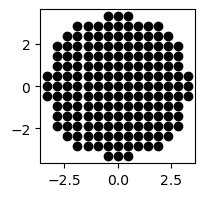

In [10]:
importlib.reload(wavefunctions)

r_ws = 10
N = 56
dim = 2
numKpoints = 169

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

NUp = N//2
NDown = N - NUp
spins = (NUp, NDown)

kpoints = wavefunctions.genKpoints(numKpoints, lattice, dim)

print(kpoints.shape)

plt.figure(figsize=(2,2))
plt.scatter(r_ws * kpoints[:,0], r_ws * kpoints[:,1], color='black')
plt.show()

(169, 2)


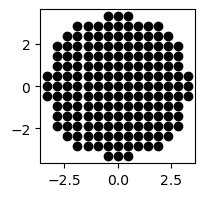

[1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1.
 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1.
 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0.
 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1.
 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1.
 0.]
[0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0.
 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0.
 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1.
 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 

ValueError: Argument to slogdet() must have shape [..., n, n], got (28, 169)

In [27]:
importlib.reload(wavefunctions)

r_ws = 10
N = 56
dim = 2
numKpoints = 169

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

NUp = N//2
NDown = N - NUp
spins = (NUp, NDown)

kpoints = wavefunctions.genKpoints(numKpoints, lattice, dim)

print(kpoints.shape)

plt.figure(figsize=(2,2))
plt.scatter(r_ws * kpoints[:,0], r_ws * kpoints[:,1], color='black')
plt.show()

rng = jax.random.PRNGKey(558)
rs = np.random.rand(spins[0],dim)
wavefunction = wavefunctions.LogSimpleSlater(spins[0], dim, kpoints)
wavefunction.init(rng, rs)